In [3]:
import pandas as pd
import netCDF4 as nc
from matplotlib import pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import numpy as np
import plotly.graph_objects as go
import kaleido

In [4]:
data_folder = "/home/j/Documents/IIASA/MM-Emulator"
figure_folder = data_folder + "/figures/new/"

def data_file_path(data_file):
    return data_folder + "/" + data_file

data00 = pd.read_csv(data_file_path('magpie_input_MP00BI00nov23.csv'))
data70 = pd.read_csv(data_file_path('magpie_input_MP00BI70nov23.csv'))
data74 = pd.read_csv(data_file_path('magpie_input_MP00BI74nov23.csv'))
data78 = pd.read_csv(data_file_path('magpie_input_MP00BI78nov23.csv'))

# Data prep

## Biomass

In [5]:
df_biomass = pd.DataFrame()

def bm_2100(data, data_target, target, source="2100"):
    df_bm = data[(data['Region']=='World') & (data['GHGscen']=="GHG000") & (data['Variable']=="Primary Energy|Biomass")]
    data_target[target] = df_bm[source]
    #df_bm = df_bm.drop(columns=["Region" , "Variable", "Unit", "SSPscen", "GHGscen", "SDGscen", "1995", "2000", "2005", "2010", "2015", "2020", "2025", "2030", "2035", "2040", "2045", "2050", "2055", "2060", "2070", "2080", "2090", "2110"])

bm_2100(data00, df_biomass, "BIOscen", "BIOscen")
bm_2100(data00, df_biomass, "BI00", "2100")
bm_2100(data70, df_biomass, "BI70", "2100")
bm_2100(data74, df_biomass, "BI74", "2100")
bm_2100(data78, df_biomass, "BI78", "2100")

df_biomass = df_biomass.drop(columns=["BIOscen"])

df_biomass 

,BI00,BI70,BI74,BI78
1286,24.2711,24.2711,24.2711,24.2711
19707,24.9631,24.2711,24.2711,24.2711
38271,103.7446,41.2551,24.6418,24.2711
56835,295.1926,85.0142,36.1713,24.2711
75399,544.8403,178.2577,81.3958,25.0536
93963,641.1249,230.9698,146.0267,36.3625
112527,652.3703,249.0520,196.9344,102.4820


In [24]:
#bio_v = ["Baseline", "Low", "Medium", "High"]
bio_v = ["B", "L", "M", "H"]



In [7]:
bm_v = [0,5,7,10,15,25,45]


## Land Use

In [8]:
land_types = ["Land Cover|Cropland", "Land Cover|Forest", "Land Cover|Other Land", "Land Cover|Pasture"]
def prep_land_data(data, bioscen='BIO45'):
    df_land = data[(data['Region']=='World') & (data['BIOscen']==bioscen) & (data['GHGscen']=='GHG000') & data['Variable'].isin(land_types) ] 
    df_land = df_land.drop(columns=["Region" , "SSPscen", "BIOscen", "SDGscen", "2110"])
    df_land["Variable"] = df_land["Variable"].str.replace("Land Cover|", "")
    return df_land

df_00 = prep_land_data(data00)
df_00

,Variable,Unit,GHGscen,1995,2000,2005,2010,2015,2020,2025,...,2035,2040,2045,2050,2055,2060,2070,2080,2090,2100
112163,Cropland,million ha,GHG000,1469.1559,1471.6257,1475.9538,1510.0286,1580.3780,1615.9719,1650.0620,...,1832.9462,1969.6661,2109.9729,2257.6421,2414.1232,2594.4728,2992.0083,3366.1334,3575.3200,3690.6959
112254,Forest,million ha,GHG000,4040.1376,4038.2434,4034.1238,4016.3582,3972.8080,3950.1161,3945.8322,...,3849.8557,3807.4774,3721.5742,3636.7382,3559.3173,3475.3650,3262.6997,3143.8803,3094.8616,3086.1112
112358,Other Land,million ha,GHG000,3965.1134,3952.1587,3945.0142,3921.8455,3890.2620,3881.5942,3849.7243,...,3798.8686,3736.2868,3699.6912,3646.9446,3610.3700,3550.3128,3397.2866,3243.2652,3173.6856,3108.1673
112371,Pasture,million ha,GHG000,3251.5087,3263.8877,3270.8238,3277.6833,3282.4677,3278.2334,3280.2970,...,3244.2450,3212.4853,3194.6772,3184.5907,3142.1051,3105.7650,3073.9209,2972.6366,2882.0483,2840.9411


In [9]:
def prepare_land_df(df, land = "Cropland",scenario = "High", indexm = 0):
    df_temp = df.copy()
    df_land_part = df_temp[df_temp['Variable']==land].drop(columns=['Unit'])
    df_land_part = df_land_part.reset_index().drop(columns=['index'])
    df_land_part = df_land_part.transpose()
    df_land_part["Year"] = df_land_part.index
    df_land_part["Land"] = land
    df_land_part = df_land_part.rename(columns={0: scenario})
    df_land_part = df_land_part.drop(["Variable", "GHGscen"])
    df_land_part = df_land_part.reset_index().drop(columns=['index'])
    df_land_part.index += len(df_land_part.index) * indexm
    df_land_part["Year"] = df_land_part["Year"].astype("int")
    return df_land_part


def prepland_df_full(df, scenario = "High"):
    land_short = ["Cropland", "Forest", "Other Land", "Pasture"]
    df_land_full = pd.DataFrame()
    for i in range(len(land_short)):
        df_land_full = pd.concat([df_land_full,prepare_land_df(df, land_short[i], scenario, i)])
    return df_land_full


def add_scenario(df, df_source, scenario):
    source = prepland_df_full(df_source, scenario)
    df[scenario] = source[scenario]


In [10]:
df_land_bii = prepland_df_full(prep_land_data(data00), "Potential")

add_scenario(df_land_bii, prep_land_data(data70), "Stop loss")
add_scenario(df_land_bii, prep_land_data(data78), "Sustainable")
add_scenario(df_land_bii, prep_land_data(data78,"BIO00"), "Minimal")

df_land_bii = df_land_bii[['Year', 'Land', 'Potential', 'Stop loss', 'Sustainable', 'Minimal']]
df_land_bii


,Year,Land,Potential,Stop loss,Sustainable,Minimal
0,1995,Cropland,1469.1559,1469.1559,1469.1559,1469.1559
1,2000,Cropland,1471.6257,1471.6257,1471.6257,1471.6257
2,2005,Cropland,1475.9538,1475.9538,1475.9538,1475.9538
3,2010,Cropland,1510.0286,1510.0286,1510.0286,1510.0286
4,2015,Cropland,1580.378,1580.378,1580.378,1580.378
...,...,...,...,...,...,...
67,2060,Pasture,3105.765,2971.9074,2464.9267,2414.6466
68,2070,Pasture,3073.9209,2902.2075,2397.6656,2304.237
69,2080,Pasture,2972.6366,2885.1564,2201.4516,2171.9975
70,2090,Pasture,2882.0483,2868.5154,1953.0848,1921.0734


# Plots

## Definitions

In [ ]:
# Color Scheme (default too dark) PuOr: ['#e66101','#fdb863', '#b2abd2', '#5e3c99']
cmap_PuOr = ListedColormap(['#e66101','#fdb863', '#b2abd2', '#5e3c99'])
ghg_labels = ["Baseline", "Low", "Medium" ,"High Climate Policy Stringency"]
fs = 20
fs_redux = 15


## Subplot 1: Bioenergy Potential

In [12]:
print(bio_v)
print(bm_v)
print(df_biomass.values)

['Baseline', 'Low', 'Medium', 'High']
[0, 5, 7, 10, 15, 25, 45]
[[ 24.2711  24.2711  24.2711  24.2711]
 [ 24.9631  24.2711  24.2711  24.2711]
 [103.7446  41.2551  24.6418  24.2711]
 [295.1926  85.0142  36.1713  24.2711]
 [544.8403 178.2577  81.3958  25.0536]
 [641.1249 230.9698 146.0267  36.3625]
 [652.3703 249.052  196.9344 102.482 ]]


In [27]:
fig = go.Figure(
    layout = go.Layout(
        template='plotly_white',
        margin=dict(l=0,r=0,b=0,t=0),
        font_size = 10,
        scene=dict(
            xaxis=dict(title ='', autorange="reversed"), #Biodiversity conservation ambition
            yaxis=dict(title="",tickmode = 'linear', tick0 = 0, dtick = 15,autorange="reversed", ticks='outside'), #Biomass Price<br>(US$2005/GJ)
            zaxis=dict(title=""), #Biomass Potential (EJ/yr)
            camera = dict(
                center = dict(z = -0.1,x = 0),
                eye = dict(x = -1,y = 2,z = 0.1)
            )            
        )
    )
)

fig.add_trace(
    go.Surface(x = bio_v,y = bm_v,z = df_biomass.values,        
        contours=dict(
            x = dict(show = True,color = "White",width = 3),
            y = dict(show = True,color = "White")
        )        
    )
)

fig.show()
fig.write_image(figure_folder + "fig2_1.png", width=800, height = 700)

## Subplot 2: Land use

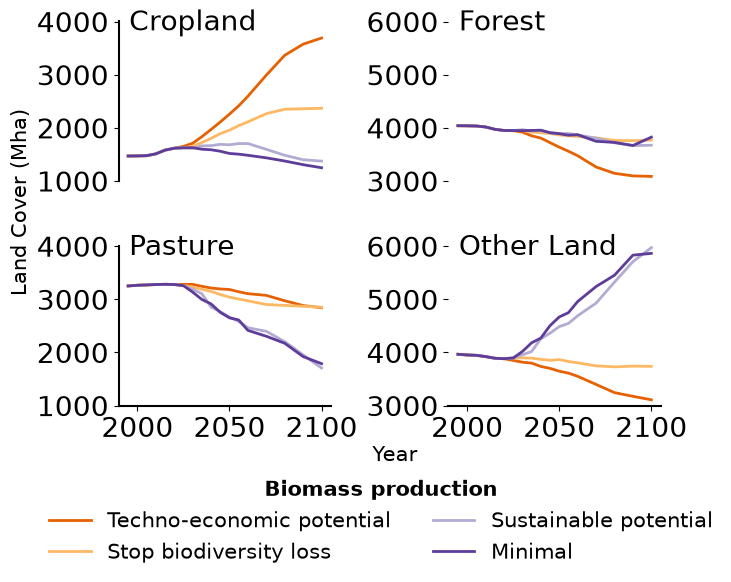

In [34]:
potentials = ['Potential', 'Stop loss', 'Sustainable', 'Minimal']
def create_subplot(landtype, axis, ylow):
    df = df_land_bii[df_land_bii['Land']==landtype]
    new_lim = [ylow-10, ylow+3010]
    new_ticks = [ylow, ylow+1000, ylow+2000, ylow+3000]
    splot = df.plot(
       ax=axis,
       x="Year",
       y=potentials,
       colormap=cmap_PuOr, 
       linewidth=2,
       legend=None,
       xticks=[2000,2050,2100],
       yticks=new_ticks,
       ylim=new_lim,
       xlabel=""
    )
    
    splot.tick_params(axis='both', which='major', labelsize=fs)
    for axis in ['top','bottom','left','right']:
        splot.spines[axis].set_linewidth(1.5)
    splot.spines.right.set_visible(False)
    splot.spines.top.set_visible(False)
    if landtype == "Cropland":
        splot.get_xaxis().set_visible(False)
        splot.spines.bottom.set_visible(False)
    elif landtype == "Forest":
        splot.spines.left.set_visible(False)
        splot.get_xaxis().set_visible(False)
        splot.spines.bottom.set_visible(False)
    elif landtype == "Other Land":
        splot.spines.left.set_visible(False)
    splot.set_title(landtype, x=0.05, y=0.89, horizontalalignment = "left", fontsize = fs)



fig2_2, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 5))
fig2_2.subplots_adjust(wspace=0.55, hspace=0.4)


create_subplot("Cropland", axes[0,0], ylow = 1000)
create_subplot("Forest", axes[0,1], ylow =3000)
create_subplot("Pasture", axes[1,0], ylow = 1000)
create_subplot("Other Land", axes[1,1], ylow = 3000)

fig2_2.text(x=0.52, y=-0, s="Year", ha='center', fontsize=fs_redux)
fig2_2.text(x=-0.03, y=0.34, s="Land Cover (Mha)", fontsize=fs_redux, rotation=90)

fig2_2.savefig(figure_folder + "fig2_2.png", bbox_inches = "tight")

handles, labels = axes[0,1].get_legend_handles_labels()
fig2_2.legend(handles, ["Techno-economic potential", "Stop biodiversity loss", "Sustainable potential", "Minimal"], loc = "upper center", bbox_to_anchor=(0.5, 0), ncol=2, title = "Biomass production", title_fontproperties = {"size":fs_redux, "weight":"bold"}, fontsize = fs_redux, frameon=False)
fig2_2.savefig(figure_folder + "fig2_2+legend.png", bbox_inches = "tight")



## Subplot 3: Maps

In [29]:
ncname = "cell.land_split_0.5.nc"
ncpath_tech = "/DisaggData/BII00/BE45/"
ncpath_sust = "/DisaggData/BII78/BE45/"

In [30]:
def netcdf_prep(ncf_path):
    xrds = xr.open_dataset(ncf_path)
    xrds = xrds.sel(Time=2100)
    return xrds['crop_kbe_ir'] + xrds['crop_kbe_rf']

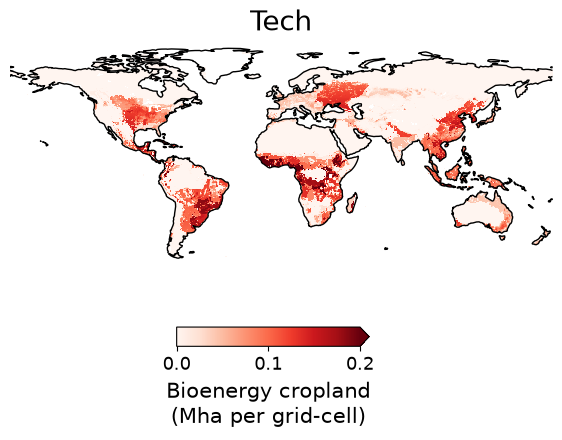

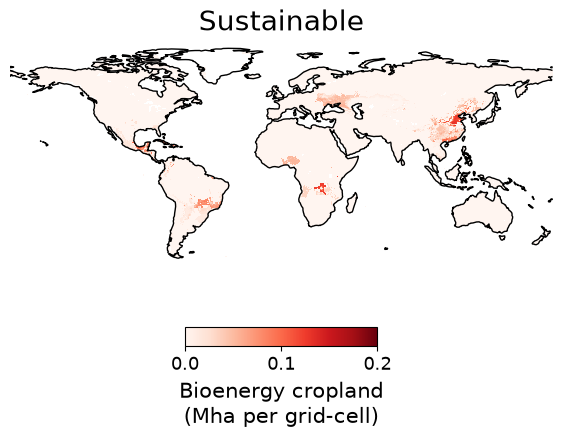

In [31]:
def plot_bm_map(ncf_path, title = "test", cb=False):
    nc = data_folder + ncf_path + ncname
    data = netcdf_prep(nc)
    fig = plt.figure(figsize=(7, 5), facecolor='white')
    ax = plt.axes(projection=ccrs.PlateCarree(), ylim=[-63,90], frameon=False)
    map = 0
    if cb:
        map = data.plot(ax=ax,transform=ccrs.PlateCarree(), vmin = 0, vmax = 0.2, cmap='Reds', cbar_kwargs={"ticks":[0,0.1,0.2],'location':"bottom", 'fraction':0.05, 'aspect': 10})
        map.colorbar.ax.tick_params(labelsize=fs_redux-2)
        map.colorbar.set_label(label = 'Bioenergy cropland\n(Mha per grid-cell)', size=fs_redux)

    else:
        map = data.plot(ax=ax,transform=ccrs.PlateCarree(), vmin = 0, vmax = 0.25, cmap='Reds', add_colorbar=False)
    ax.coastlines()
    plt.title(title, loc='center',fontsize = fs, horizontalalignment = "center")
    return fig


map_base = plot_bm_map(ncpath_tech, "Tech", True)
map_base.savefig(figure_folder + "fig2_3a+legend.png", bbox_inches = "tight")

map_high = plot_bm_map(ncpath_sust, "Sustainable", True)
map_high.savefig(figure_folder + "fig2_3b+legend.png", bbox_inches = "tight")


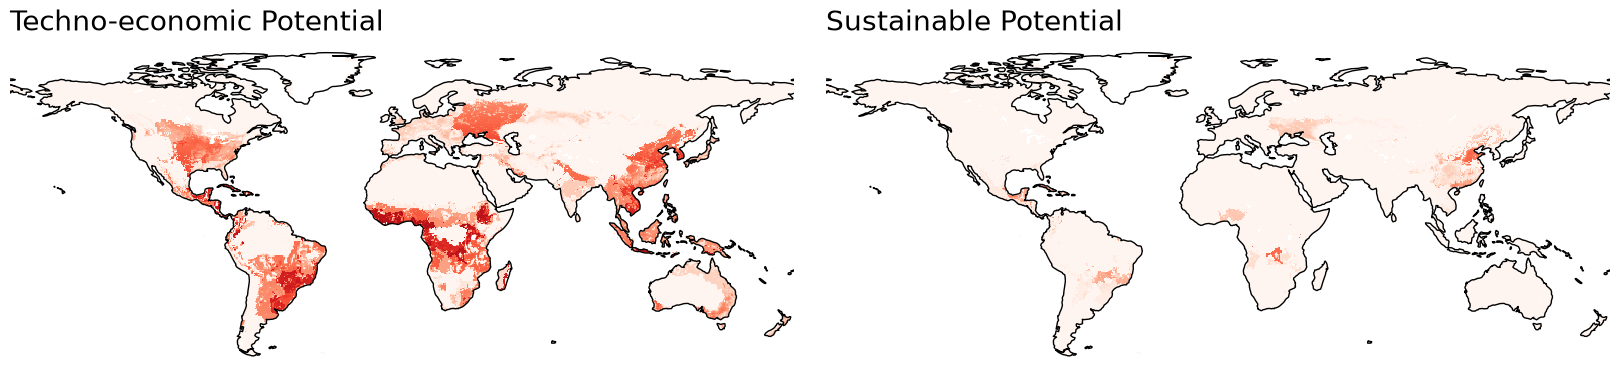

In [33]:
def plot_bm_ax(ncf_path, axis, title = "test", cb=False):
    nc = data_folder + ncf_path + ncname
    data = netcdf_prep(nc)
    map = 0
    if cb:
        map = data.plot(ax=axis,transform=ccrs.PlateCarree(), vmin = 0, vmax = 0.2, cmap='Reds', cbar_kwargs={"ticks":[0,0.1,0.2],'location':"bottom", 'fraction':0.05, 'aspect': 10})
        map.colorbar.ax.tick_params(labelsize=fs_redux-2)
        map.colorbar.set_label(label = 'Bioenergy cropland\n(Mha per grid-cell)', size=fs_redux)

    else:
        map = data.plot(ax=axis,transform=ccrs.PlateCarree(), vmin = 0, vmax = 0.25, cmap='Reds', add_colorbar=False)
    axis.coastlines()
    axis.set_title("")
    axis.set_title(title, loc='left',fontsize = fs, horizontalalignment = "left")

fig2_3, axes = plt.subplots(1, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree(), 'ylim':[-63,90], 'frameon':False})
plot_bm_ax(ncpath_tech, axes[0], "Techno-economic Potential", False)
plot_bm_ax(ncpath_sust, axes[1], "Sustainable Potential", False)
axes[0].set_position([0, 0, 0.49, 0.49])
axes[1].set_position([0.51, 0, 0.49, 0.49])

fig2_3.savefig(figure_folder + "fig2_3.png", bbox_inches = "tight")
